In [325]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # Embeds full JS for HTML export

In [326]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [327]:
# Analyze the original dataset
df_CellDNA=pd.read_csv("ML_HW_Data_CellDNA-1.csv",header=None)
print("Shape : ", df_CellDNA.shape)
print('********************************************')
print("checking for null columns :\n ", df_CellDNA.isnull().sum())
print('********************************************')
print("describe: \n ",df_CellDNA.describe())
print('********************************************')

Shape :  (1217, 14)
********************************************
checking for null columns :
  0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64
********************************************
describe: 
                  0            1            2            3            4   \
count  1217.000000  1217.000000  1217.000000  1217.000000  1217.000000   
mean    200.366475   419.476953   211.335155    33.388599     9.376939   
std     135.665649   215.563920   141.592818    19.152143     3.634969   
min      70.000000    28.176471    27.870130    10.282437     3.080963   
25%     107.000000   243.400000    96.200000    18.760441     7.529888   
50%     160.000000   415.360000   183.834286    27.832476     8.463304   
75%     252.000000   611.128440   292.824742    44.462419     9.801152   
max    1089.000000   773.919643   575.340206   155.330123    43.487111   

                5            6            7            

There is no missing data in the original dataset. 
We can proceed with the analysis without needing to handle missing values. 
Keeping only the relevant columns for further analysis.

In [328]:
X_df = df_CellDNA.drop(columns=[13])  # Features DataFrame
X = zscore(X_df, axis=0).values  #  standardized value (zscore per column ) 
y=np.where(df_CellDNA[13].values==0,0,1)  # Target variable (last column)

In [329]:
X_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,222,31.189189,40.342342,35.579087,8.883917,0.968325,-80.113673,222,1,16.812471,0.816176,0.578125,78.591
1,73,29.493151,271.397260,15.517202,6.407490,0.910764,76.042946,73,1,9.640876,0.858824,0.608333,39.217
2,256,58.816406,289.941406,37.226013,9.863895,0.964256,85.324742,256,1,18.054067,0.752941,0.562637,89.111
3,126,71.023810,477.412698,13.112980,12.790672,0.220351,63.523477,126,1,12.666025,0.881119,0.646154,43.832
4,225,90.808889,541.946667,44.463110,7.858879,0.984256,-52.874983,225,1,16.925688,0.728155,0.252525,90.072


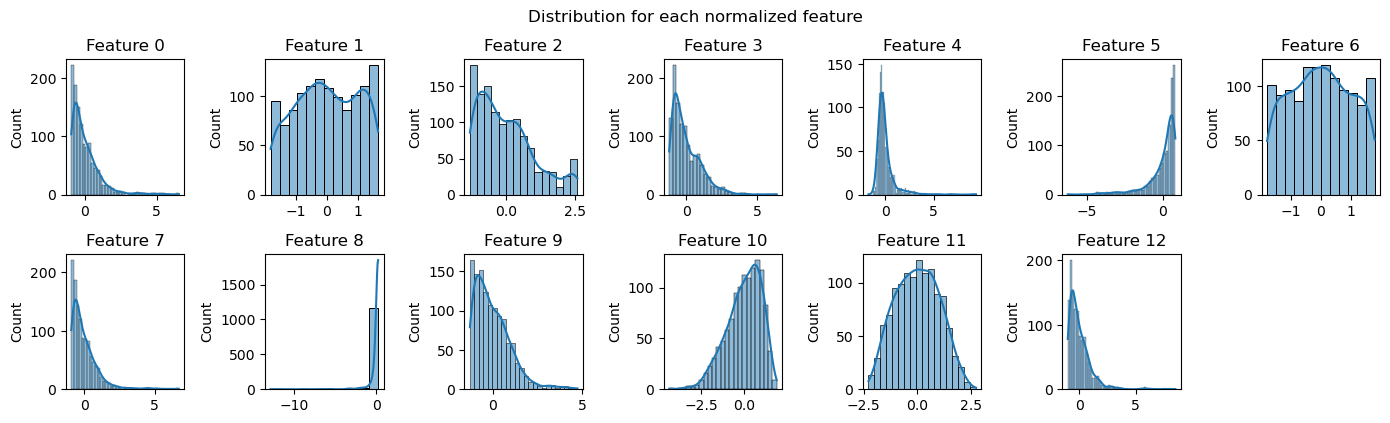

In [330]:
plot_num = plt.figure(figsize=(14, 8))
plt.suptitle('Distribution for each normalized feature')

plotnum = 1
for i in range(X.shape[1]):
    plt.subplot(4, 7, plotnum)
    sn.histplot(X[:, i], kde=True)
    plt.title(f'Feature {i}')
    plotnum += 1

plt.tight_layout()
plt.show()

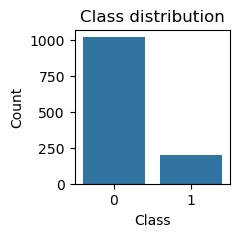

In [331]:
plt.figure(figsize=(2, 2))
sn.countplot(x=Y)
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [332]:
# Fit SVM on all data
svm_model = SVC(kernel='linear', probability=True, random_state=1234)
svm_model.fit(X, Y)


SVC(kernel='linear', probability=True, random_state=1234)

In [333]:
# Support vectors
print('Support vectors per class:', svm_model.n_support_)
print('Total support vectors:', svm_model.support_vectors_.shape[0])

Support vectors per class: [115 113]
Total support vectors: 228


In [334]:
# Scores and probabilities
svm_decision = svm_model.decision_function(X)
svm_prob_class1 = svm_model.predict_proba(X)[:, 1]

In [335]:
# Top 3 smallest absolute decision values
smallest_idx = np.argsort(np.abs(svm_decision))[:3]
print('Top 3 records with smallest absolute decision values:')
for idx in smallest_idx:
    print(f'Record {idx+1}: decision={svm_decision[idx]:.6f}, abs={abs(svm_decision[idx]):.6f}, true_class={Y[idx]}, prob_class1={svm_prob_class1[idx]:.6f}')



Top 3 records with smallest absolute decision values:
Record 781: decision=-0.003266, abs=0.003266, true_class=1, prob_class1=0.488624
Record 463: decision=-0.004384, abs=0.004384, true_class=1, prob_class1=0.488176
Record 340: decision=-0.005284, abs=0.005284, true_class=1, prob_class1=0.487816


In [336]:
# Requested records
req_idx = [130, 164, 891, 1056]
print('Requested records:')
for idx in req_idx:
    print(f'Record {idx+1}: decision={svm_decision[idx]:.6f}, prob_class1={svm_prob_class1[idx]:.6f}, true_class={Y[idx]}')

Requested records:
Record 131: decision=-21.177568, prob_class1=0.000000, true_class=0
Record 165: decision=9.342155, prob_class1=1.000000, true_class=1
Record 892: decision=4.584146, prob_class1=0.999999, true_class=1
Record 1057: decision=-26.296517, prob_class1=0.000000, true_class=0


In [337]:
# Precision / recall / F1 for both classes
y_pred_svm = svm_model.predict(X)
report = classification_report(Y, y_pred_svm, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
print(report_df[['precision', 'recall', 'f1-score', 'support']])

              precision    recall  f1-score      support
0              0.943853  0.958702  0.951220  1017.000000
1              0.771739  0.710000  0.739583   200.000000
accuracy       0.917831  0.917831  0.917831     0.917831
macro avg      0.857796  0.834351  0.845401  1217.000000
weighted avg   0.915568  0.917831  0.916440  1217.000000


In [338]:
# ROC for binary classification
fpr0, tpr0, _ = roc_curve(Y, -svm_decision)   # class 0
fpr1, tpr1, _ = roc_curve(Y, svm_decision)    # class 1

auc0 = auc(fpr0, tpr0)
auc1 = auc(fpr1, tpr1)

print('Class 0 AUC:', auc0)
print('Class 1 AUC:', auc1)


Class 0 AUC: 0.031396263520157335
Class 1 AUC: 0.9686037364798427


Class 0 AUC: 0.9686037364798427
Class 1 AUC: 0.9686037364798427


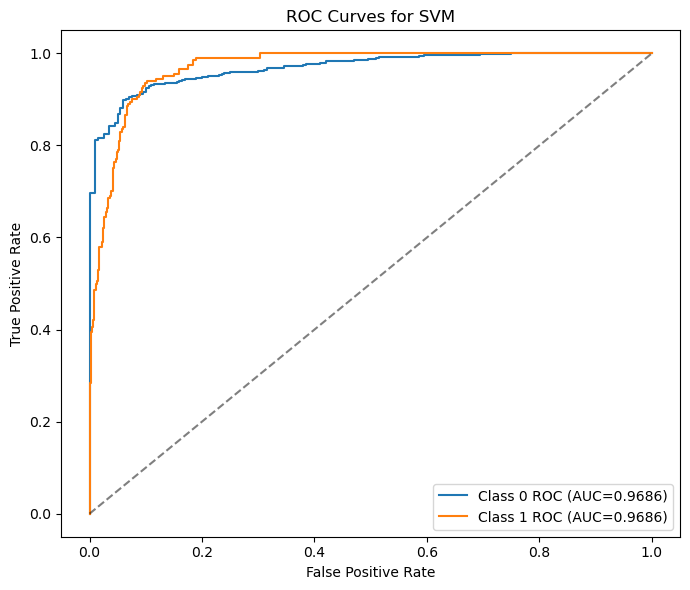

In [348]:
y_score = svm_model.decision_function(X)

# ROC for class 1
fpr1, tpr1, _ = roc_curve(Y, y_score,pos_label=1)
auc1 = auc(fpr1, tpr1)

# ROC for class 0
fpr0, tpr0, _ = roc_curve(Y, -y_score,pos_label=0)
auc0 = auc(fpr0, tpr0)

print('Class 0 AUC:', auc0)
print('Class 1 AUC:', auc1)

plt.figure(figsize=(7,6))
plt.plot(fpr0, tpr0, label=f'Class 0 ROC (AUC={auc0:.4f})')
plt.plot(fpr1, tpr1, label=f'Class 1 ROC (AUC={auc1:.4f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for SVM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
